## Info 

Here I am testing some functions from the functions.py area. I will not include this in the git.

In [19]:
import random
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D


import importlib

import functions as fns
importlib.reload(fns)

import configuration as cfg
importlib.reload(cfg)

LHAPDF 6.5.5 loading /home/fusco-linux/LHAPDF/share/LHAPDF/cteq6l1/cteq6l1_0000.dat
cteq6l1 PDF set, member #0, version 4; LHAPDF ID = 10042


<module 'configuration' from '/home/fusco-linux/Code/DRToM/configuration.py'>

In [20]:
# ======================================================================
# Verify all IDmap_2toX maps (2→2, 2→3, 2→4, 2→5) produce valid ID lists
# ======================================================================

import inspect
import functions as fns  # or whatever module name your functions are in

# Dummy test IDs
ID1, ID2 = 1, -1
outIDs = [2, -2]  # pretend outgoing quark pair
dummy_incoming = [ID1, ID2] + outIDs  # [1, -1, 2, -2]

# Collect all IDmap_2toX dicts dynamically from the module
IDmap_dicts = {
    name: obj
    for name, obj in inspect.getmembers(fns)
    if name.startswith("IDmap_2to") and isinstance(obj, dict)
}

print("Checking IDmap_2toX functions...\n")

for map_name, IDmap in IDmap_dicts.items():
    n_final = int(map_name.split("to")[1])  # e.g. "2to3" → 3
    expected_len = 2 + n_final
    print(f"--- {map_name} ---")
    for interaction_name, processes in IDmap.items():
        for proc_name, id_generator in processes:
            try:
                FullIDs = id_generator(dummy_incoming)
            except Exception as e:
                print(f"[ERROR] {interaction_name} -> {proc_name} raised exception: {e}")
                continue

            if not isinstance(FullIDs, list):
                print(f"[BAD] {interaction_name} -> {proc_name} did not return a list: {FullIDs}")
                continue

            if len(FullIDs) != expected_len:
                print(f"[BAD] {interaction_name} -> {proc_name} produces {len(FullIDs)} IDs (expected {expected_len}): {FullIDs}")
            else:
                print(f"[OK]  {interaction_name} -> {proc_name} produces {len(FullIDs)} IDs: {FullIDs}")
    print()

print("All IDmap checks complete.")

Checking IDmap_2toX functions...

--- IDmap_2to2 ---
[OK]  gg_gg -> gg_gg produces 4 IDs: [1, -1, 2, -2]
[OK]  gg_qqx -> gg_qqx produces 4 IDs: [1, -1, 2, -2]
[OK]  qqx_gg -> qqx_gg produces 4 IDs: [1, -1, 2, -2]
[OK]  gq_gq -> gq_gq produces 4 IDs: [1, -1, 2, -2]
[OK]  gqx_gqx -> gqx_gqx produces 4 IDs: [1, -1, 2, -2]
[OK]  qqp_qqp -> qqp_qqp produces 4 IDs: [1, -1, 2, -2]
[OK]  qqpx_qqpx -> qqpx_qqpx produces 4 IDs: [1, -1, 2, -2]
[OK]  qxqpx_qxqpx -> qxqpx_qxqpx produces 4 IDs: [1, -1, 2, -2]
[OK]  qqx_qpqpx -> qqx_qpqpx produces 4 IDs: [1, -1, 2, -2]
[OK]  qq_qq -> qq_qq produces 4 IDs: [1, -1, 2, -2]
[OK]  qxqx_qxqx -> qxqx_qxqx produces 4 IDs: [1, -1, 2, -2]
[OK]  qqx_qqx -> qqx_qqx produces 4 IDs: [1, -1, 2, -2]

--- IDmap_2to3 ---
[OK]  gg_gg -> gg_ggg produces 5 IDs: [21, 21, 21, 21, 21]
[OK]  gg_gg -> gg_qqxg produces 5 IDs: [21, 21, 4, -4, 21]
[OK]  gg_qqx -> gg_qqxg produces 5 IDs: [21, 21, 2, -2, 21]
[OK]  qqx_gg -> qqx_ggg produces 5 IDs: [1, -1, 21, 21, 21]
[OK]  qqx_gg 

In [7]:
def print_subprocess_combinations():
    for subprocess in cfg.all_subprocesses:
        # Use pretty name if available, else raw subprocess string
        pretty = cfg.pretty_names.get(subprocess, subprocess)
        print(f"\nSubprocess: {pretty}")

        combos = fns.subprocess_combinations(subprocess)

        seen = set()
        for ID1, ID2, func in combos:
            key = (ID1, ID2, func.__name__)
            if key in seen:
                print(f"  [DUPLICATE?] ID1={ID1}, ID2={ID2}, Func={func.__name__}")
            else:
                seen.add(key)
                print(f"  ID1, ID2 = {ID1}, {ID2}")  #, Func={func.__name__}")

        print(f"  → total combos = {len(combos)}, unique = {len(seen)}")

print_subprocess_combinations()


Subprocess: gg → gg
  ID1, ID2 = 21, 21
  → total combos = 1, unique = 1

Subprocess: gg → qq̄
  ID1, ID2 = 21, 21
  → total combos = 1, unique = 1

Subprocess: qq̄ → gg
  ID1, ID2 = 1, -1
  ID1, ID2 = 2, -2
  ID1, ID2 = 3, -3
  ID1, ID2 = 4, -4
  ID1, ID2 = 5, -5
  ID1, ID2 = 6, -6
  → total combos = 6, unique = 6

Subprocess: gq → gq
  ID1, ID2 = 21, 1
  ID1, ID2 = 21, 2
  ID1, ID2 = 21, 3
  ID1, ID2 = 21, 4
  ID1, ID2 = 21, 5
  ID1, ID2 = 21, 6
  → total combos = 6, unique = 6

Subprocess: gq̄ → gq̄
  ID1, ID2 = 21, -1
  ID1, ID2 = 21, -2
  ID1, ID2 = 21, -3
  ID1, ID2 = 21, -4
  ID1, ID2 = 21, -5
  ID1, ID2 = 21, -6
  → total combos = 6, unique = 6

Subprocess: qq' → qq'
  ID1, ID2 = 1, 2
  ID1, ID2 = 1, 3
  ID1, ID2 = 1, 4
  ID1, ID2 = 1, 5
  ID1, ID2 = 1, 6
  ID1, ID2 = 2, 3
  ID1, ID2 = 2, 4
  ID1, ID2 = 2, 5
  ID1, ID2 = 2, 6
  ID1, ID2 = 3, 4
  ID1, ID2 = 3, 5
  ID1, ID2 = 3, 6
  ID1, ID2 = 4, 5
  ID1, ID2 = 4, 6
  ID1, ID2 = 5, 6
  → total combos = 15, unique = 15

Subproces

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], marker='o', color='w', label='Λ₃ = 3 TeV', markerfacecolor='purple'),
    Line2D([0], [0], marker='s', color='w', label='Λ₃ = 4 TeV', markerfacecolor='navy'),
    Line2D([0], [0], marker='D', color='w', label='Λ₃ = 5 TeV', markerfacecolor='teal'),
    Line2D([0], [0], marker='^', color='w', label='Λ₃ = 6 TeV', markerfacecolor='mediumturquoise'),
    Line2D([0], [0], marker='v', color='w', label='Λ₃ = 7 TeV', markerfacecolor='limegreen'),
    Line2D([0], [0], marker='<', color='w', label='SM QCD', markerfacecolor='gold'),
]

fig_legend = plt.figure(figsize=(8, 1))

fig_legend.legend(
    handles=handles,
    loc='center',
    ncol=6,
    frameon=True,
    markerscale=1.6,
    handletextpad=0.2,   # space between marker and text
    columnspacing=0.65,   # space between legend columns
    labelspacing=0.3     # vertical spacing (not huge here since 1 row)
)

fig_legend.savefig("legend_only.png", bbox_inches='tight', transparent=True, dpi=300)
plt.show()  # <--- pops it up in the terminal window

<Figure size 800x100 with 0 Axes>

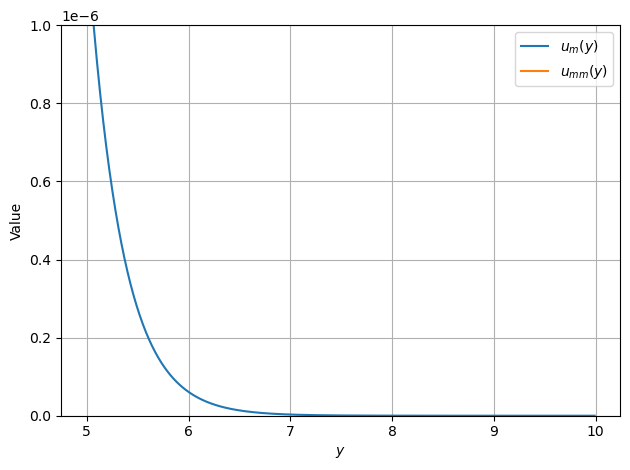

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# domain for y
y = np.arange(5, 10, 0.01)        # choose a reasonable range & step

def um(y):
    return np.sqrt(2 * np.cosh(2*y) - 1) / (np.cosh(2*y)**2 - 1)

def umm(y):
    return 1 / (2 * np.cosh(y))

# vectorised evaluation
um_vals = um(y)
umm_vals = umm(y)

# plot
plt.plot(y, um_vals, label=r'$u_m(y)$')
plt.plot(y, umm_vals, label=r'$u_{mm}(y)$')
plt.xlabel(r'$y$')
plt.ylabel('Value')
plt.ylim(0, 1e-6)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

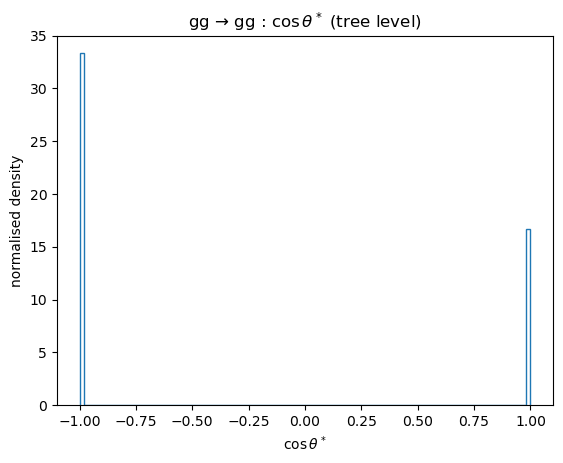

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- constants (arbitrary overall g_s factor cancels in shape) ---
alpha_s = 0.118
g_s = np.sqrt(4*np.pi*alpha_s)

# amplitude-squared for gg -> gg (summed/avg over colours & spins)
# see e.g. Ellis-Stirling-Webber, eq. for gg->gg
def M2(s, t, u):
    return (9/2) * g_s**4 * (
        3
        - (u * t) / s**2
        - (s * u) / t**2
        - (s * t) / u**2
    )

# generate flat phase-space (massless 2->2)
def generate_flat_events(n, s_hat):
    # energies in cm frame
    E = np.sqrt(s_hat) / 2
    p = E
    # random cosθ and φ
    costh = np.random.uniform(-1, 1, n)
    phi = np.random.uniform(0, 2*np.pi, n)
    return costh, phi, p, E

# Monte Carlo
N = 200000
s_hat = (1000.0)**2  # GeV^2, just a scale

costh, phi, p, E = generate_flat_events(N, s_hat)
theta = np.arccos(costh)

# Mandelstam variables (massless)
t = -0.5 * s_hat * (1 - costh)
u = -0.5 * s_hat * (1 + costh)

weights = M2(s_hat, t, u)

# accept/reject to get unweighted events
prob = weights / weights.max()
mask = np.random.rand(N) < prob
accepted_costh = costh[mask]

# Plot
plt.hist(accepted_costh, bins=100, density=True, histtype="step")
plt.xlabel(r"$\cos\theta^*$")
plt.ylabel("normalised density")
plt.title(r"gg $\to$ gg : $\cos\theta^*$ (tree level)")
plt.show()


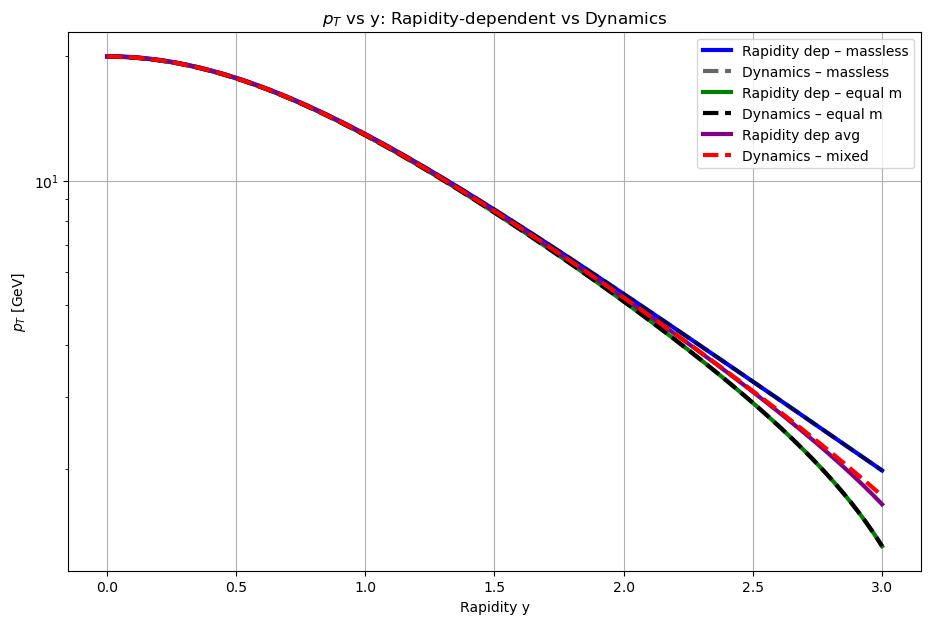

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------------------------
# Parameters
# ---------------------------
M = 40
m = 1.5
Randomy_vals = np.linspace(0.001, 3, 200)

# ---------------------------
# Rapidity-dependent pT
# ---------------------------
def pt_rapidity_dep(M, y, m3, m4):
    """
    pT = sqrt( E3^2 * sech^2(y) - m3^2 )
    with E3 = (M^2 + m3^2 - m4^2)/(2M)
    """
    E3 = (M**2 + m3**2 - m4**2) / (2*M)
    val = E3**2 / np.cosh(y)**2 - m3**2
    return np.sqrt(val) if val > 0 else np.nan

# Compute pT for each case
pt_rd_massless = [pt_rapidity_dep(M, y, 0, 0) for y in Randomy_vals]
pt_rd_equal    = [pt_rapidity_dep(M, y, m, m) for y in Randomy_vals]

pt_rd_m3_0  = [pt_rapidity_dep(M, y, 0, m) for y in Randomy_vals]
pt_rd_m4_0  = [pt_rapidity_dep(M, y, m, 0) for y in Randomy_vals]
pt_rd_mixed_avg = [(a+b)/2 for a,b in zip(pt_rd_m3_0, pt_rd_m4_0)]

# ---------------------------
# Dynamics formulas
# ---------------------------
def pt_massless_massless(M, y):
    return 0.5 * M / math.cosh(y)

def pt_equal_mass(M, y, Qmass):
    return 0.5 / math.cosh(y) * math.sqrt(M**2 - 4 * Qmass**2 * math.cosh(y)**2)

def pt_massless_massive(M, y, Qmass):
    a = math.sqrt(2) * math.sqrt(
        (math.cosh(2*y)**2) *
        (Qmass**4 * math.cosh(4*y) - Qmass**4 + 2*(M**4))
    ) / (math.cosh(2*y)**2 - 1)
    b = (2*Qmass**2 * math.cosh(2*y)**2) / (math.cosh(2*y)**2 - 1)
    c = (2*Qmass**2) / (math.cosh(2*y)**2 - 1)
    d = (2*M**2) / (math.cosh(2*y)**2 - 1)
    return 0.5 * math.sqrt(a - b + c - d)

pt_dyn_massless = [pt_massless_massless(M, y) for y in Randomy_vals]
pt_dyn_equal    = [pt_equal_mass(M, y, m) for y in Randomy_vals]
pt_dyn_mixed    = [pt_massless_massive(M, y, m) for y in Randomy_vals]

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(11,7))

# Massless
plt.plot(Randomy_vals, pt_rd_massless, 'b-', lw=3, label='Rapidity dep – massless')
plt.plot(Randomy_vals, pt_dyn_massless, 'k--', lw=3, alpha=0.6, label='Dynamics – massless')

# Equal mass
plt.plot(Randomy_vals, pt_rd_equal, 'g-', lw=3, label='Rapidity dep – equal m')
plt.plot(Randomy_vals, pt_dyn_equal, 'k--', lw=3, label='Dynamics – equal m')

# Mixed massless/massive
# plt.plot(Randomy_vals, pt_rd_m3_0,  color='red', lw=2.5, label='Rapidity dep (m3=0,m4=m)')
# plt.plot(Randomy_vals, pt_rd_m4_0,  color='orange', lw=2.5, label='Rapidity dep (m3=m,m4=0)')
plt.plot(Randomy_vals, pt_rd_mixed_avg, color='purple', lw=3, label='Rapidity dep avg')
plt.plot(Randomy_vals, pt_dyn_mixed, 'r--', lw=3, label='Dynamics – mixed')



plt.xlabel('Rapidity y')
plt.ylabel(r'$p_T$ [GeV]')
plt.yscale('log')
plt.title(r'$p_T$ vs y: Rapidity-dependent vs Dynamics')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Parameters
M = 1000.0                  # invariant mass in GeV
y_values = np.linspace(2, 2.5, 200)  # partonic rapidity


# Mandelstam variables
that = -0.5 * M**2 * np.exp(-y_values) / np.cosh(y_values)
uhat = -0.5 * M**2 * np.exp(y_values) / np.cosh(y_values)

plt.figure(figsize=(8,5))
plt.plot(y_values, that, label='t')
plt.plot(y_values, uhat, '--', label='u')
plt.xlabel('y')
plt.ylabel('t, u')
#plt.yscale("log") 
plt.title(fr"M={M} GeV") #, $\sqrt{{s}}$={np.sqrt(s):.1f} GeV")
plt.legend()
plt.grid(True)
plt.show()


y_test = 100    
print(-0.5 * M**2 * np.exp(-y_test) / np.cosh(y_test))
print(-0.5 * M**2 * np.exp(y_test) / np.cosh(y_test))

In [ ]:
# Parameters
M = 1000.0        # invariant mass in GeV
s = 5000**2       # CoM energy squared in GeV^2
yMax = 2.5        # maximum rapidity

N_samples = 100000

# Compute tau and Ymax for this M
tau = M**2 / s
Ymax_M = min(np.log(1 / np.sqrt(tau)), yMax)

# Generate random Y in [-Ymax_M, Ymax_M]
RandomY = np.random.uniform(-Ymax_M + 1e-9, Ymax_M - 1e-9, N_samples)

# Generate Randomy constrained by Y
Randomy = np.random.uniform(-(yMax - np.abs(RandomY)), yMax - np.abs(RandomY))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.hist(Randomy, bins=200, color="royalblue", alpha=0.7, edgecolor="black")
plt.xlabel(r"$y$", fontsize=14)
plt.ylabel(f"Events / {5/200}", fontsize=14)
plt.title(fr"Distribution of 'Randomy' for M={M} GeV, $\sqrt{{s}}$={np.sqrt(s):.1f} GeV, Ymax_M={Ymax_M:.2f}", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
